In [41]:
import pandas as pd
#Load dataset
df=pd.read_csv('../data/bank.csv',na_values=['',' ','-'])

display(df.head())
df.info()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction.Score,Card.Type,Point.Earned
0,Hargrave,619,France,Female,NaN,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,NaN,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Surname             4897 non-null   str    
 1   CreditScore         4898 non-null   int64  
 2   Geography           4896 non-null   str    
 3   Gender              4898 non-null   str    
 4   Age                 4895 non-null   float64
 5   Tenure              4898 non-null   int64  
 6   Balance             4898 non-null   float64
 7   NumOfProducts       4898 non-null   int64  
 8   HasCrCard           4898 non-null   int64  
 9   IsActiveMember      4898 non-null   int64  
 10  EstimatedSalary     4898 non-null   float64
 11  Exited              4898 non-null   int64  
 12  Satisfaction.Score  4898 non-null   int64  
 13  Card.Type           4898 non-null   str    
 14  Point.Earned        4898 non-null   int64  
dtypes: float64(3), int64(8), str(4)
memory usage: 574.1 KB


In [42]:
#Checking missing values
print(df.isna().sum())

Surname               1
CreditScore           0
Geography             2
Gender                0
Age                   3
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Satisfaction.Score    0
Card.Type             0
Point.Earned          0
dtype: int64


In [43]:
import numpy as np
# Convert target variable Exited into a binary variable Stayed
# 1 - customer stayed in the bank
# 0 - customer left the bank

df['Stayed']=np.where(df['Exited']==0,'Yes','No')
df['Stayed']=df['Stayed'].map({'Yes':1,'No':0})

df.drop(columns='Exited',inplace=True)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Surname             4897 non-null   str    
 1   CreditScore         4898 non-null   int64  
 2   Geography           4896 non-null   str    
 3   Gender              4898 non-null   str    
 4   Age                 4895 non-null   float64
 5   Tenure              4898 non-null   int64  
 6   Balance             4898 non-null   float64
 7   NumOfProducts       4898 non-null   int64  
 8   HasCrCard           4898 non-null   int64  
 9   IsActiveMember      4898 non-null   int64  
 10  EstimatedSalary     4898 non-null   float64
 11  Satisfaction.Score  4898 non-null   int64  
 12  Card.Type           4898 non-null   str    
 13  Point.Earned        4898 non-null   int64  
 14  Stayed              4898 non-null   int64  
dtypes: float64(3), int64(8), str(4)
memory usage: 574.1 KB
None


In [44]:
# Replace missing values with median
df['Age']=df['Age'].fillna(df['Age'].median())
df=df[df['Age']<=87]

In [45]:
print(df.isnull().sum())
df.drop(columns='Surname',inplace=True)
#Surname is categorical variable, irrelevant for model

Surname               1
CreditScore           0
Geography             2
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Satisfaction.Score    0
Card.Type             0
Point.Earned          0
Stayed                0
dtype: int64


In [46]:

df.dropna(inplace=True)

In [47]:
import matplotlib.pyplot as plt
import seaborn as sb

def draw_kdeplot(column):
    plt.figure(figsize=(6,4))
    sb.kdeplot(data=df,x=column,hue='Stayed',fill=True,alpha=0.5)
    plt.show()


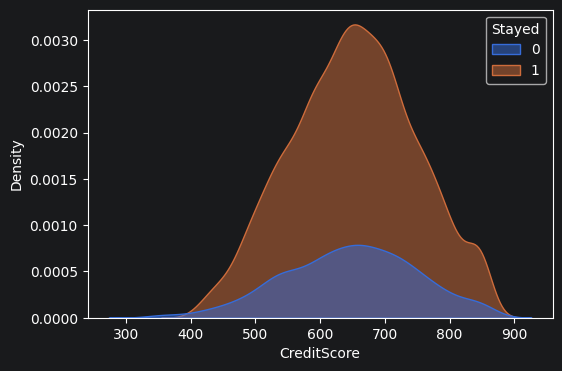

In [48]:
draw_kdeplot('CreditScore')
df.drop(columns='CreditScore',inplace=True)
# The distributions of CreditScore overlap significantly,
# meaning that this variable does not clearly separate
# customers who stayed and customers who left.
# Therefore, it will not provide important information
# for classification.

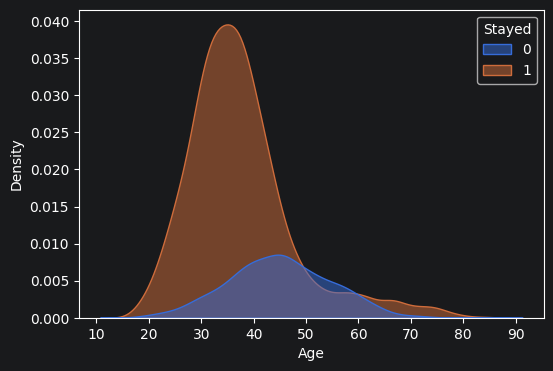

In [49]:
draw_kdeplot('Age')
# Age shows differences between the two classes.
# Older customers are more likely to leave the bank,
# therefore this variable will be kept.

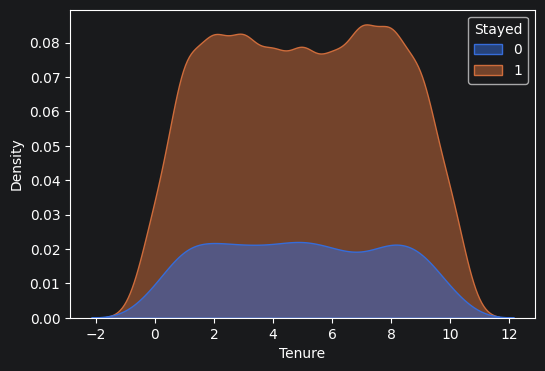

In [50]:
draw_kdeplot('Tenure')
df.drop(columns='Tenure',inplace=True)


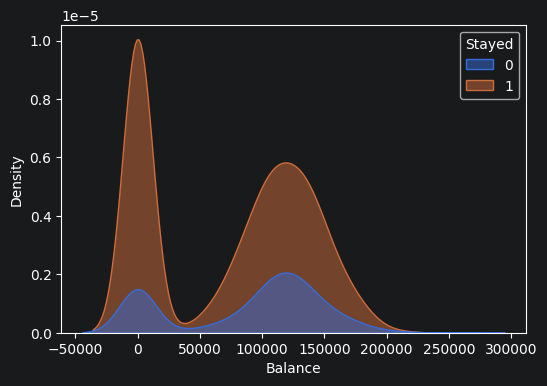

In [51]:
draw_kdeplot('Balance')

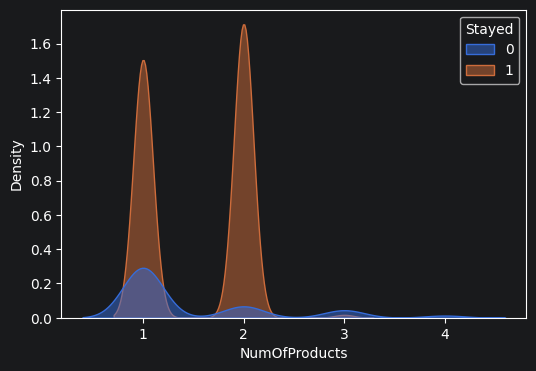

In [52]:
draw_kdeplot('NumOfProducts')

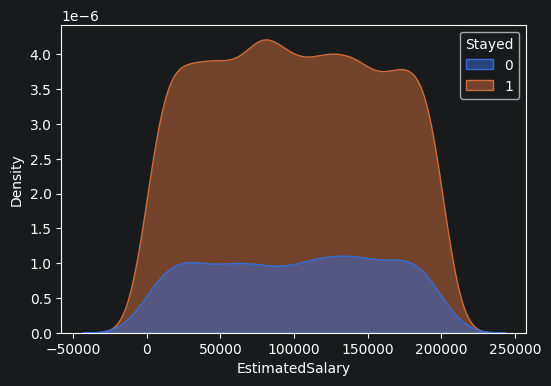

In [53]:
draw_kdeplot('EstimatedSalary')
df.drop(columns='EstimatedSalary',inplace=True)

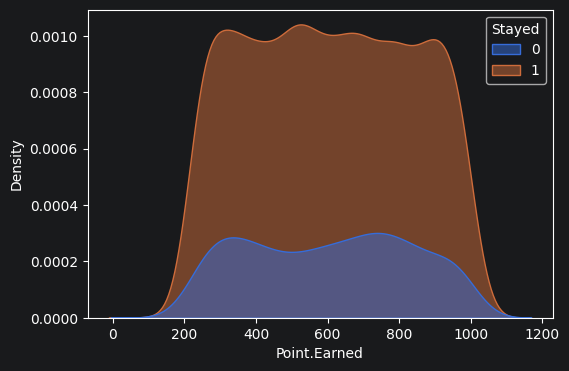

In [54]:
draw_kdeplot('Point.Earned')
df.drop(columns='Point.Earned',inplace=True)

In [55]:
def draw_countplot(column):
    plt.figure(figsize=(6,4))
    sb.countplot(data=df,x=column,hue='Stayed',palette='pastel')
    plt.show()

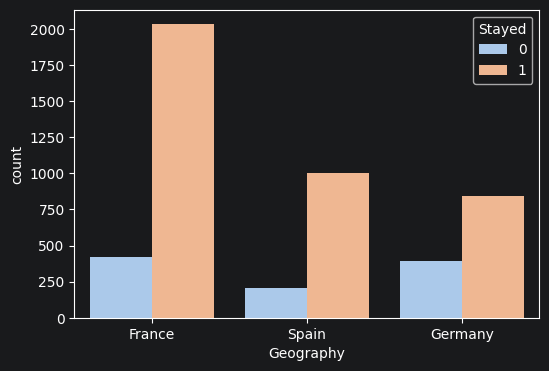

In [56]:
draw_countplot('Geography')

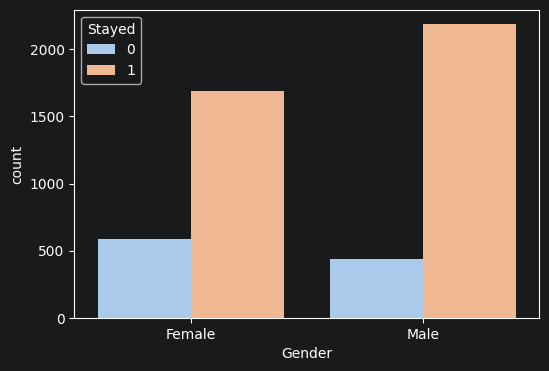

In [57]:
draw_countplot('Gender')

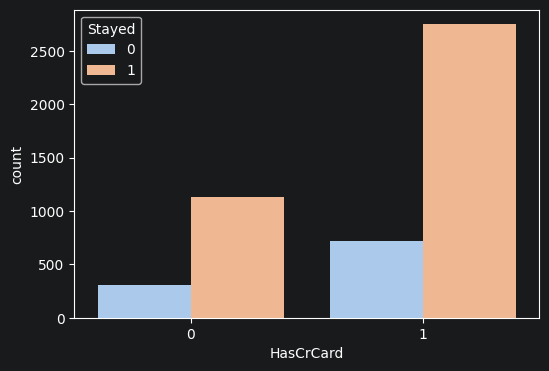

In [58]:
draw_countplot('HasCrCard')
df.drop(columns='HasCrCard',inplace=True)

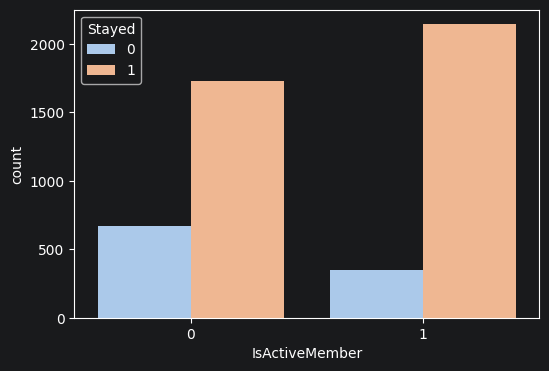

In [59]:
draw_countplot('IsActiveMember')

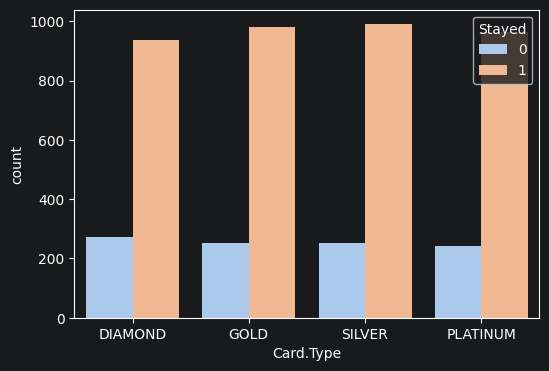

In [60]:
draw_countplot('Card.Type')
df.drop(columns='Card.Type',inplace=True)

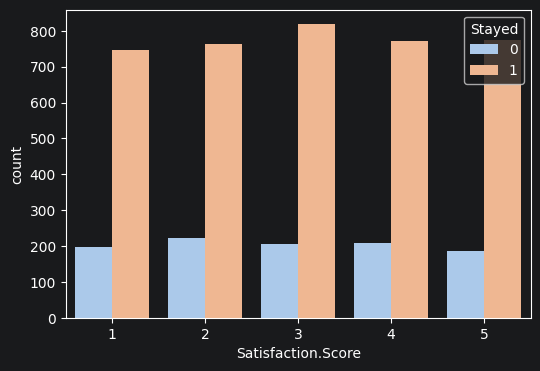

In [61]:
draw_countplot('Satisfaction.Score')
df.drop(columns='Satisfaction.Score',inplace=True)

In [62]:
df=pd.get_dummies(df,columns=['Geography'],drop_first=True,dtype=int)
df = pd.get_dummies(df, columns=['Gender'], drop_first=True,dtype=int)
# Categorical variables are transformed into numerical variables using one-hot encoding.
# One category is removed (drop_first=True) to avoid multicollinearity.

In [63]:
from sklearn.model_selection import StratifiedKFold,GridSearchCV,train_test_split

X=df.drop(columns='Stayed')
y=df['Stayed']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=7,stratify=y)

In [64]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
tree=DecisionTreeClassifier(random_state=42)
cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
param_grid={'ccp_alpha':np.arange(0.0,0.05,0.0025)}
grid=GridSearchCV(tree,
                  cv=cv,
                  param_grid=param_grid,
                  scoring='accuracy')
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': array([0. ...045 , 0.0475])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is 

In [65]:
best_alpha = grid.best_params_['ccp_alpha']
print("Best ccp_alpha:", best_alpha)

tree=DecisionTreeClassifier(ccp_alpha=best_alpha,random_state=42)
tree.fit(X_train,y_train)

Best ccp_alpha: 0.0025


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

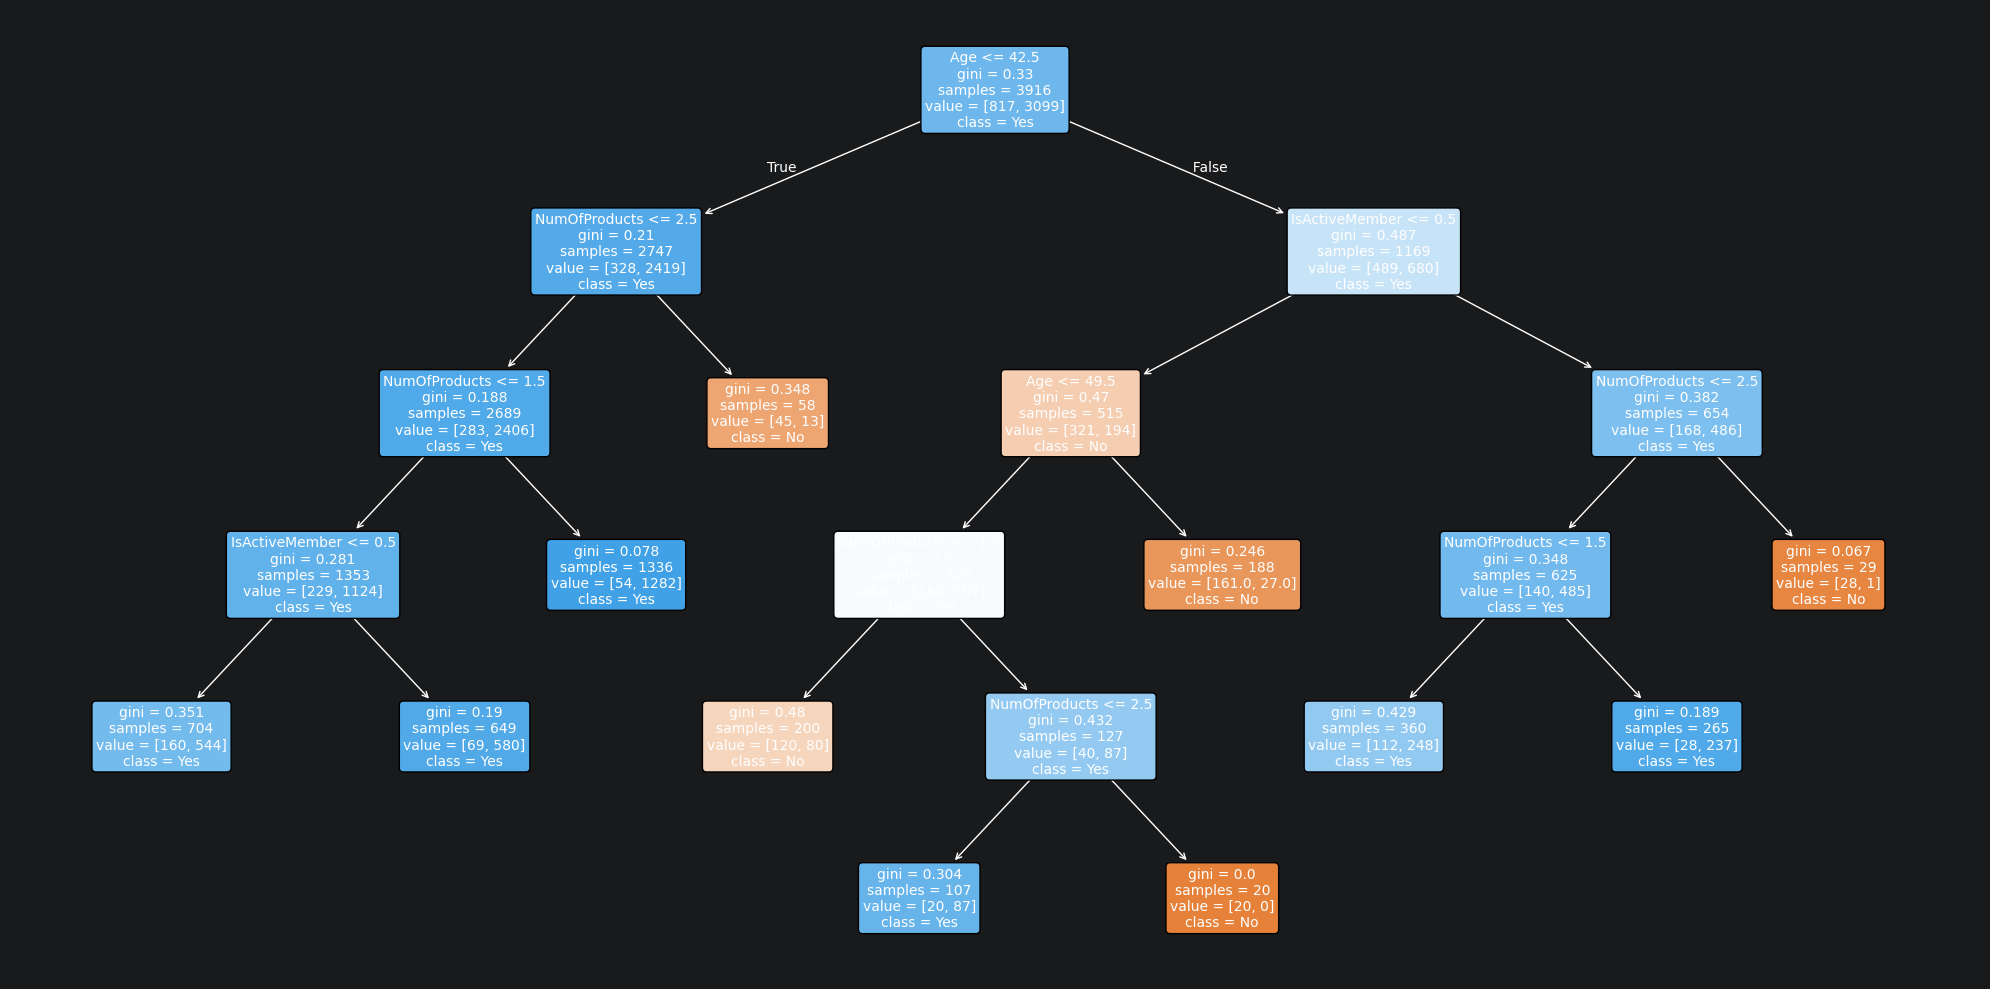

In [66]:
plt.figure(figsize=(20,10))
plot_tree(tree,class_names=['No','Yes'],feature_names=X_train.columns,rounded=True,filled=True,fontsize=10)
plt.tight_layout()
plt.show()

In [67]:
y_pred=tree.predict(X_test)

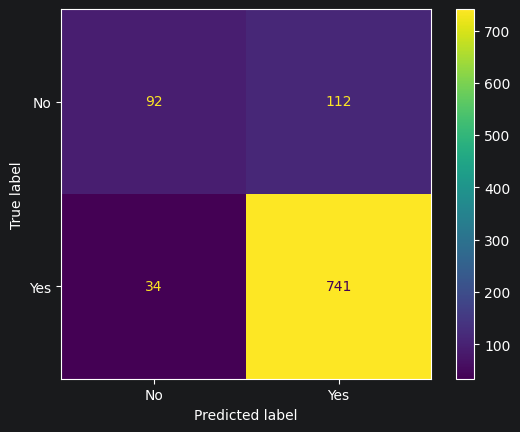

In [68]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,ConfusionMatrixDisplay

cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(cm,display_labels=['No','Yes'])
disp.plot()
plt.show()

The confusion matrix contains four possible outcomes:

True Positive (TP) - the number of customers predicted by the model to stay in the bank who actually stayed. The model correctly identified 741 customers.

True Negative (TN) - the number of customers predicted by the model to leave the bank who actually left. The model correctly classified 92 customers.

False Positive (FP) - the number of customers predicted by the model to stay in the bank, but who actually left. The model incorrectly classified 112 customers.

False Negative (FN) - the number of customers predicted by the model to leave the bank, but who actually stayed. The model incorrectly classified 34 customers.

In [69]:
def compute_evil_metrics(y_true,y_pred):
    acc=accuracy_score(y_true,y_pred)
    precision=precision_score(y_true,y_pred)
    recall=recall_score(y_true,y_pred)
    f1=f1_score(y_true,y_pred)

    return{
        'accuracy':acc,
        'precision':precision,
        'recall':recall,
        'f1':f1,
    }

In [70]:
metrics=compute_evil_metrics(y_test,y_pred)
print(metrics)

# Model performance is evaluated using four metrics:
#
# Accuracy - percentage of correctly classified samples
# Precision - proportion of correct positive predictions
# Recall - proportion of actual positive samples detected
# F1-score - balance between precision and recall

{'accuracy': 0.8508682328907048, 'precision': 0.8686987104337632, 'recall': 0.9561290322580646, 'f1': 0.9103194103194103}


Accuracy shows that the model correctly classified a high percentage of customers regarding whether they stayed in the bank or left.

Precision indicates that among all customers predicted by the model as customers who would stay in the bank, 87% of them actually stayed.

Recall shows that among all customers who actually stayed in the bank, the model correctly identified 95.6% of them.

F1-score indicates a good balance between precision and recall. Since both metrics have high values, the F1-score is also high (0.91), which means that the model makes relatively few classification errors when predicting customer retention.